# 125 — ships_sent / ships_src across all episodes

Loops over every replay in `110-replays/53402535/`, extracts winner actions,
and boxplots `ships_sent / ships_src` grouped by `ships_src`.
Uses the previous step's planet snapshot for `ships_src` (accurate pre-dispatch count).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

REPLAY_DIR = Path("110-replays/53402535")
EPISODE_IDS = [
    78867640, 78899068, 78982947, 79033183,
    79126912, 79175592, 79228392, 79320069,
]
replay_files = [REPLAY_DIR / f"episode_{ep}.json" for ep in EPISODE_IDS]
print(f"Episodes: {len(replay_files)}")
for f in replay_files:
    print(f"  {f.name}  exists={f.exists()}")

Episodes: 8
  episode_78867640.json  exists=True
  episode_78899068.json  exists=True
  episode_78982947.json  exists=True
  episode_79033183.json  exists=True
  episode_79126912.json  exists=True
  episode_79175592.json  exists=True
  episode_79228392.json  exists=True
  episode_79320069.json  exists=True


In [2]:
rows = []
for fpath in replay_files:
    ep_id = int(fpath.stem.split("_")[1])
    with open(fpath, encoding="utf-8") as f:
        ep = json.load(f)

    prev_planet_ships = None
    for step in ep["steps"]:
        obs = step[0]["observation"]
        planet_ships = {int(p[0]): p[5] for p in obs.get("planets", [])}
        game_step = obs.get("step", 0)
        if prev_planet_ships is not None:
            for action in (step[0].get("action") or []):
                src_id = int(action[0])
                rows.append({
                    "episode":    ep_id,
                    "game_step":  game_step,
                    "id_src":     src_id,
                    "ships_sent": action[2],
                    "ships_src":  prev_planet_ships.get(src_id, float("nan")),
                })
        prev_planet_ships = planet_ships

df = pd.DataFrame(rows)
print(f"Total actions: {len(df):,}")
df.head(10)

Total actions: 2,069


,episode,game_step,id_src,ships_sent,ships_src
0,78867640,12,12,21.0,21
1,78867640,15,12,3.0,3
2,78867640,18,12,3.0,3
3,78867640,20,20,22.0,22
4,78867640,21,12,3.0,3
5,78867640,23,20,12.0,12
6,78867640,26,20,12.0,12
7,78867640,34,12,13.0,13
8,78867640,35,18,18.0,18
9,78867640,37,20,46.0,46


C:\Users\trant\AppData\Local\Temp\ipykernel_1832\26848509.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


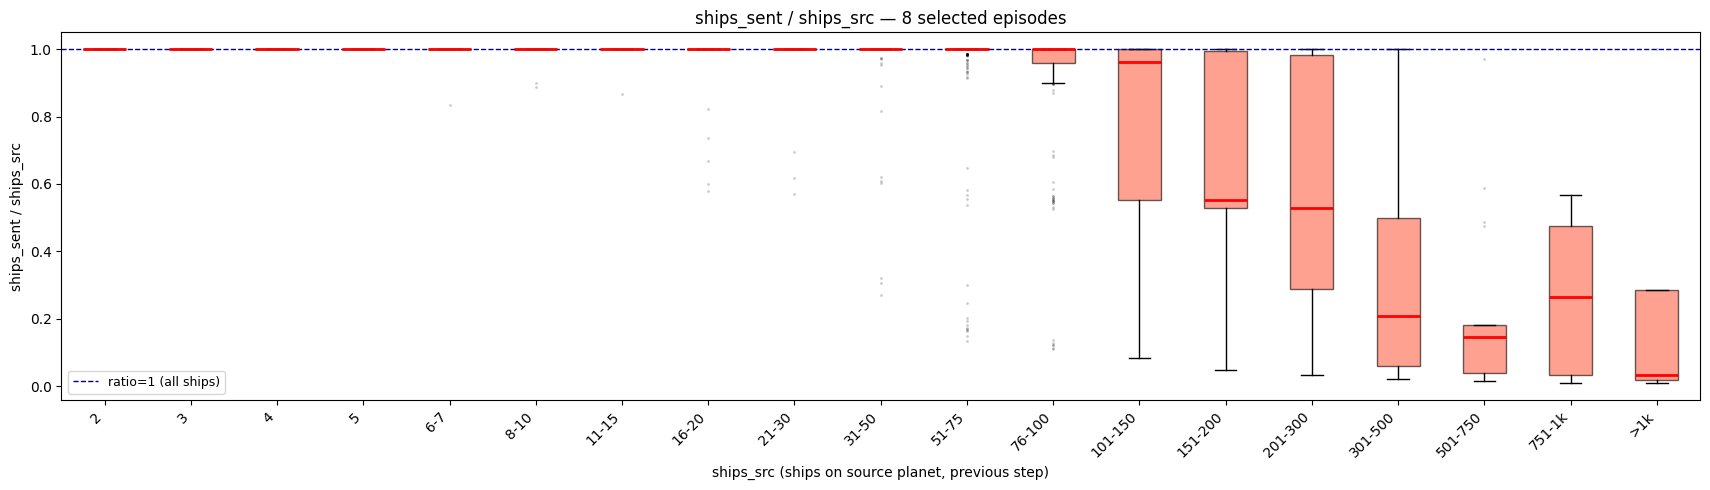

Saved 125-ships_sent_per_src_selected.png


In [3]:
# Bin ships_src into log-spaced buckets for a readable boxplot
bins  = [0, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000, float("inf")]
labels = ["1", "2", "3", "4", "5", "6-7", "8-10", "11-15", "16-20",
          "21-30", "31-50", "51-75", "76-100", "101-150", "151-200",
          "201-300", "301-500", "501-750", "751-1k", ">1k"]
df["ships_src_bin"] = pd.cut(df["ships_src"], bins=bins, labels=labels, right=True)

src_order = [l for l in labels if l in df["ships_src_bin"].cat.categories and
             df["ships_src_bin"].eq(l).any()]
data = [(df.loc[df["ships_src_bin"] == s, "ships_sent"] /
         df.loc[df["ships_src_bin"] == s, "ships_src"]).dropna().values
        for s in src_order]

fig, ax = plt.subplots(figsize=(max(10, len(src_order) * 0.8 + 2), 5))
ax.boxplot(
    data,
    labels=src_order,
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2),
    boxprops=dict(facecolor="tomato", alpha=0.6),
    flierprops=dict(marker=".", markersize=2, alpha=0.2),
)
ax.axhline(1.0, color="navy", linestyle="--", linewidth=1, label="ratio=1 (all ships)")
ax.set_xlabel("ships_src (ships on source planet, previous step)")
ax.set_ylabel("ships_sent / ships_src")
ax.set_title(f"ships_sent / ships_src — {len(EPISODE_IDS)} selected episodes")
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("125-ships_sent_per_src_selected.png", dpi=150)
plt.show()
print(f"Saved 125-ships_sent_per_src_selected.png")

In [7]:
df_ = pd.read_parquet("114-precompute/78867640/df_s.parquet")
df_

,id,step,x,y,ships,owner,production,nature
0,2,263,97.046577,29.736102,43,-1,1,fix
1,8,374,96.190608,71.761827,85,-1,1,fix
2,4,114,90.547027,83.563411,76,1,4,fix
3,17,175,37.334021,12.649760,70,0,1,moving
4,21,88,85.687650,42.525175,81,1,3,moving
...,...,...,...,...,...,...,...,...
17263,15,294,55.479747,17.088560,204,0,1,moving
17264,12,105,75.605954,28.610151,26,1,1,moving
17265,17,409,16.024356,70.028056,304,0,1,moving
17266,11,66,3.809392,28.238173,85,-1,1,fix


In [8]:
pd.read_parquet("114-precompute/78867640/actions.parquet")

,game_step,id_src,angle,ships_sent,id
0,12,12,-0.023063,21,20
1,15,12,0.206614,3,20
2,18,12,0.344946,3,20
3,20,20,-0.711544,22,22
4,21,12,0.483278,3,20
...,...,...,...,...,...
83,298,21,1.300859,296,16
84,303,5,-0.330617,382,20
85,322,7,1.483946,335,20
86,466,23,-1.957416,446,17


In [10]:
pd.read_parquet("114-precompute/78867640/reach.parquet")

,id_src,step_src,id,step,ships_sent
0,9,396,15,409,512
1,9,438,25,449,16
2,19,142,10,150,256
3,4,352,24,362,1
4,23,369,21,382,32
...,...,...,...,...,...
4172987,2,222,28,234,32
4172988,31,357,1,366,512
4172989,1,128,13,134,512
4172990,2,39,29,48,1024
